# Predicting car prices with scikit-learn

This notebook is the companion to [`car-price-prediction.ipynb`](car-price-prediction.ipynb), which builds a linear regression model for car prices **from scratch with NumPy**. Here we build the same model again, step by step, but let scikit-learn do the training.

Same data, same cleaning, same train/validation/test split, same features. So wherever the two notebooks should agree, they should agree to many decimal places, which is a good check that both are right. The more interesting part is where they *don't* agree. In the NumPy notebook the model broke three times, and every time it was the same rule being broken:

> **No column may be an exact recipe of the other columns.**

scikit-learn trains through all three cases without an error or a warning. Sections 6, 8 and 9 look at why, and at what that silence costs.

**Contents**
1. Preparing the dataset
2. Train, validation and test sets
3. A first model: `LinearRegression`
4. Adding the age of the car
5. A categorical feature: number of doors
6. Cars with 0 doors: where the two notebooks part ways
7. The fix: drop one door column
8. The make of the car
9. Ridge regression
10. The final model: one look at the test set
11. NumPy vs scikit-learn, side by side

## Setup

The same environment as the NumPy notebook, plus scikit-learn:

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows
source .venv/bin/activate       # macOS / Linux
pip install numpy pandas scikit-learn matplotlib ipykernel
```

This notebook was written with Python 3.12, NumPy 2, pandas 3, scikit-learn 1.9 and Matplotlib 3.

In [1]:
# Every chart in this notebook shares one look: a light background, thin grey gridlines, and a fixed order
# of colors (blue, then orange, then green), so that a color keeps its meaning within a chart.
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#898781'
BACKGROUND, INK = '#fcfcfb', '#0b0b0b'

plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'text.color': INK,
    'legend.frameon': False,
    'lines.linewidth': 2,
    'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, GREEN]),
})

## 1. Preparing the dataset

The preparation is the same as in section 1 of the NumPy notebook, so the explanations are kept short here: tidy up the column names and the text, add the log of the price as the target (`msrp_log`), and fill the missing values with 0.

In [2]:
# Download the dataset from a public source (only if we don't have it yet).
# Python's urllib works the same on Windows, macOS and Linux, unlike !wget or !curl.
from pathlib import Path
from urllib.request import urlretrieve

url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

if not Path('data.csv').exists():
    urlretrieve(url, 'data.csv')

In [3]:
# Now let's look at the data with pandas.
import numpy as np
import pandas as pd

df = pd.read_csv('data.csv')

# the first 5 rows of the data frame
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
# The table is not quite ready to use yet. The column names are inconsistent: some are capitalized and
# some contain spaces (e.g. 'Engine HP', 'highway MPG'), which makes them awkward to type.
print(df.columns.tolist())

# Let's make them lower case and replace the spaces with underscores.
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']
['make', 'model', 'year', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'city_mpg', 'popularity', 'msrp']


In [5]:
# The text entries have the same problem ('BMW' vs 'bmw'), so let's lower-case them too.
# .str.lower() only works on text columns, so first we find the columns that contain text.
strings = [col for col in df.columns if pd.api.types.is_string_dtype(df[col])]
print(strings)

for col in strings:
    df[col] = df[col].str.lower()

df.head()

['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1 series m,2011,premium unleaded (required),335.0,6.0,manual,rear wheel drive,2.0,"factory tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [6]:
# The mean price is far above the median because of a few very expensive cars.
print(df.msrp.describe().round())

# Instead of overwriting msrp, we add a new column with the log price.
df['msrp_log'] = np.log1p(df.msrp)

df[['msrp', 'msrp_log']].head()

count      11914.0
mean       40595.0
std        60109.0
min         2000.0
25%        21000.0
50%        29995.0
75%        42231.0
max      2065902.0
Name: msrp, dtype: float64


,msrp,msrp_log
0,46135,10.739349
1,40650,10.612779
2,36350,10.500977
3,29450,10.290483
4,34500,10.448744


In [7]:
# Another issue: some entries are missing (NaN, null). Let's count them in each column.
print(df.isna().sum())

# For this tutorial, we simply fill every missing value with 0. This is a shortcut, not a careful choice,
# and in section 6 we will see that it has consequences.
df = df.fillna(0)

print('missing values left:', df.isna().sum().sum())

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
msrp_log                0
dtype: int64
missing values left: 0


## 2. Train, validation and test sets

scikit-learn has its own splitting function, `train_test_split`. We don't use it here. Instead we reuse the `dataflow` function from the NumPy notebook, so that every car lands in exactly the same set as it did there: 60% train, 20% validation, 20% test, seed 0. With identical splits, any difference between the two notebooks can only come from the training itself.

As in the NumPy notebook, models are compared on the validation set, and the test set is used once, in section 10.

In [8]:
import random

def dataflow(df: pd.DataFrame, train_ratio: float = 0.6, valid_ratio: float = 0.2, seed: int = 0):
    N = len(df)

    # We shuffle the rows before splitting. But we want the SAME shuffle every time we run this,
    # otherwise each run trains on a different split and we get a different rmse every time
    # (which makes it impossible to tell if a new feature really helped).
    # random.Random(seed) gives us our own generator, so we don't disturb the global random state.
    rng = random.Random(seed)
    random_list = rng.sample(range(N), N)

    len_train = int(train_ratio * N)
    len_valid = int(valid_ratio * N)

    # random_list contains POSITIONS (0, 1, 2, ... N-1), so we select with .iloc, which is
    # position-based. .loc would be label-based: it only works by luck while the index is
    # still 0..N-1, and breaks silently as soon as we drop or filter rows (which we will do later).
    df_train = df.iloc[random_list[:len_train]]
    df_valid = df.iloc[random_list[len_train:len_train + len_valid]]
    df_test = df.iloc[random_list[len_train + len_valid:]]

    # train + validation together: for training the final model at the very end
    df_train_valid = pd.concat([df_train, df_valid])

    assert len(df_train) + len(df_valid) + len(df_test) == N

    return {'df_train': df_train, 'df_valid': df_valid, 'df_test': df_test, 'df_train_valid': df_train_valid}


# let's create the split
dataset = dataflow(df)

df_train = dataset['df_train']
df_valid = dataset['df_valid']
df_test = dataset['df_test']

len(df_train), len(df_valid), len(df_test)

(7148, 2382, 2384)

## 3. A first model: `LinearRegression`

In the NumPy notebook we trained the model by solving the normal equation ourselves, $w = (X^T X)^{-1} X^T y$, after adding a column of 1's to the input matrix for the bias. With scikit-learn, training is one line: `LinearRegression().fit(X, y)`.

Two differences are worth knowing:

- There is no column of 1's. `LinearRegression` fits the bias by itself and stores it in `intercept_`; the feature weights are in `coef_`.
- We can pass pandas columns directly. The model remembers their names and expects the same columns whenever it predicts.

In [9]:
from sklearn.linear_model import LinearRegression

# The same four numerical features as the first NumPy model.
base = ['engine_hp', 'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base]
y_train = df_train['msrp_log']

X_valid = df_valid[base]
y_valid = df_valid['msrp_log']

In [10]:
reg = LinearRegression().fit(X_train, y_train)

print('intercept:', reg.intercept_)
print('weights:  ', reg.coef_)

# The first 5 validation cars: the real log price next to the predicted one.
pd.DataFrame({'real': y_valid[:5], 'predicted': reg.predict(X_valid[:5])})

intercept: 7.179078364633879
weights:   [ 8.06725008e-03  2.20253340e-02  1.92695701e-02 -2.26188856e-05]


,real,predicted
2582,10.051951,10.055394
8186,10.113181,9.581950
9333,10.422162,10.341287
2664,7.796058,9.532046
5136,10.417837,10.499550


In [11]:
from sklearn.metrics import root_mean_squared_error

error = root_mean_squared_error(y_valid, reg.predict(X_valid))
error

0.7734149758173121

The NumPy notebook got 0.7734149758173117 for this model, so the two agree to 15 decimal places. The difference in the last digit is rounding noise.

In [12]:
# A user-friendly prediction: give the features of a car, get its price in dollars.
def predict_price(engine_hp, highway_mpg, city_mpg, popularity):
    # One row with the same column names the model was trained on. A bare NumPy array works too,
    # but then scikit-learn warns that the column names are missing.
    car = pd.DataFrame([[engine_hp, highway_mpg, city_mpg, popularity]], columns=base)
    log_price = reg.predict(car)[0]
    return np.expm1(log_price)  # from the log scale back to dollars


# The same example car as in the NumPy notebook, which also priced it at $37,481.
predict_price(engine_hp=300, highway_mpg=24, city_mpg=21, popularity=40)

np.float64(37481.057105309024)

## 4. Adding the age of the car

In [13]:
# The newest cars in the data are from 2017, so we measure the age relative to 2017: the newest cars have age 0.
df['car_age'] = df.year.max() - df.year

df[['year', 'car_age']].head()

,year,car_age
0,2011,6
1,2011,6
2,2011,6
3,2011,6
4,2011,6


In [14]:
# df has a new column, so we split it again. The seed is fixed, so we get exactly the same split as before.
dataset = dataflow(df)
df_train = dataset['df_train']
df_valid = dataset['df_valid']

features = base + ['car_age']
reg_2 = LinearRegression().fit(df_train[features], df_train['msrp_log'])

root_mean_squared_error(df_valid['msrp_log'], reg_2.predict(df_valid[features]))

0.5301071427639958

From 0.773 to 0.530, the same improvement as in the NumPy notebook: the age of a car matters a lot.

## 5. A categorical feature: number of doors

The door count is a label rather than a quantity, so, as in the NumPy notebook, we one-hot encode it: one 0/1 column per door count. (scikit-learn's `OneHotEncoder` can build these columns for us; building them by hand keeps them identical to the NumPy notebook's.)

In [15]:
# How many cars have each door count?
print(df.number_of_doors.value_counts())

# The 0's are not real door counts: they are the missing values we filled with 0 earlier,
# so we don't create a column for them.
door_counts = sorted(int(n) for n in df.number_of_doors.unique() if n != 0)

for num in door_counts:
    df[f'has_{num}_doors'] = (df.number_of_doors == num).astype(int)

df[['number_of_doors', 'has_2_doors', 'has_3_doors', 'has_4_doors']].head(20)

number_of_doors
4.0    8353
2.0    3160
3.0     395
0.0       6
Name: count, dtype: int64


,number_of_doors,has_2_doors,has_3_doors,has_4_doors
0,2.0,1,0,0
1,2.0,1,0,0
2,2.0,1,0,0
3,2.0,1,0,0
4,2.0,1,0,0
5,2.0,1,0,0
6,2.0,1,0,0
7,2.0,1,0,0
8,2.0,1,0,0
9,2.0,1,0,0


In [16]:
# We split again so the new columns are included (same seed, so the same split).
dataset = dataflow(df)
df_train = dataset['df_train']
df_valid = dataset['df_valid']

features = base + ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors']
reg_3 = LinearRegression().fit(df_train[features], df_train['msrp_log'])

root_mean_squared_error(df_valid['msrp_log'], reg_3.predict(df_valid[features]))

0.5279430277592098

0.530 → 0.528: the doors barely change anything, just as in the NumPy notebook.

Every experiment from here on repeats the same steps: split, train on the training set, score on the validation set. Let's put them into one function.

In [17]:
# Split the data, train the model on the training set, and measure the RMSE on the validation set.
# It returns the trained model too, so that we can look inside it.
def train_and_score(df, features, model=None, seed=0):
    # A new LinearRegression for every call. Writing model=LinearRegression() in the signature would create
    # one model when the `def` runs and share it between all calls.
    if model is None:
        model = LinearRegression()

    dataset = dataflow(df, seed=seed)
    df_train = dataset['df_train']
    df_valid = dataset['df_valid']

    model.fit(df_train[features], df_train['msrp_log'])
    error = root_mean_squared_error(df_valid['msrp_log'], model.predict(df_valid[features]))

    return model, error

## 6. Cars with 0 doors: where the two notebooks part ways

6 cars have `number_of_doors == 0`. No car really has zero doors: their door count was missing, and our `fillna(0)` turned it into a 0.

In [18]:
df[df.number_of_doors == 0][['make', 'model', 'year', 'number_of_doors', 'msrp']]

,make,model,year,number_of_doors,msrp
4666,ferrari,ff,2013,0.0,295000
6930,tesla,model s,2016,0.0,79500
6931,tesla,model s,2016,0.0,66000
6932,tesla,model s,2016,0.0,134500
6933,tesla,model s,2016,0.0,74500
6934,tesla,model s,2016,0.0,71000


In [19]:
# We don't know their real door count, and they are only 6 out of 11,914 cars, so let's remove them.
indexes = df[df.number_of_doors == 0].index
df_corrected = df.drop(indexes)

print(len(df), len(df_corrected))

11914 11908


In the NumPy notebook, the next step was a shock: the same model on `df_corrected` gave an RMSE of **16.5**. Removing 6 cars out of almost 12,000 had broken it. Here is the same model with scikit-learn:

In [20]:
# The same columns as reg_3, trained on df_corrected instead of df.
features = base + ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors']

reg_4, error = train_and_score(df_corrected, features)
error

0.5143033573362288

0.5143, with no error and no warning. The predictions look sensible too:

In [21]:
# A few validation cars in dollars: the real price, the model trained with the 6 cars (reg_3),
# and the model trained without them (reg_4).
cars = dataflow(df_corrected)['df_valid'].head()

pd.DataFrame({
    'make': cars.make,
    'model': cars.model,
    'real price': cars.msrp,
    'reg_3 (with the 6 cars)': np.expm1(reg_3.predict(cars[features])).round(),
    'reg_4 (without them)': np.expm1(reg_4.predict(cars[features])).round(),
})

,make,model,real price,reg_3 (with the 6 cars),reg_4 (without them)
7769,infiniti,q45,58100,26825.0,26423.0
2631,chevrolet,c/k 1500 series,2925,6131.0,6098.0
11454,subaru,wrx,34495,50604.0,50239.0
2582,honda,civic,23200,28121.0,28011.0
8184,dodge,ram pickup 1500,25065,31859.0,31826.0


### Why scikit-learn doesn't break

The problem itself has not gone away. Without the 6 cars, every car has exactly one door column equal to 1, so for every car

`has_2_doors + has_3_doors + has_4_doors = 1`

The bias is also "1 for every car", so we can add any number to the bias and subtract the same number from all three door weights without changing a single prediction. There are infinitely many equally good sets of weights. (The NumPy notebook works through this with four real cars.)

The two notebooks react to that differently:

- **NumPy**: `np.linalg.inv(X.T @ X)` assumes there is exactly one answer. Mathematically the inverse doesn't exist, but rounding errors hide that, so it quietly returns meaningless weights. Hence the 16.5.
- **scikit-learn**: `LinearRegression` never computes an inverse. It uses a least-squares solver (`scipy.linalg.lstsq`), which first counts how many columns carry genuinely new information (the **rank**, stored in `rank_`) and, when there are infinitely many best answers, returns the one with the smallest weights.

In [22]:
# Both models have 8 columns, but reg_4 found only 7 independent ones.
print('rank of reg_3 (with the 6 cars):   ', reg_3.rank_, 'of', len(reg_3.coef_))
print('rank of reg_4 (without the 6 cars):', reg_4.rank_, 'of', len(reg_4.coef_))

print()
print('door weights of reg_3:', reg_3.coef_[-3:])
print('door weights of reg_4:', reg_4.coef_[-3:])
print(f"sum of reg_4's door weights: {reg_4.coef_[-3:].sum():.1e}")

rank of reg_3 (with the 6 cars):    8 of 8
rank of reg_4 (without the 6 cars): 7 of 8

door weights of reg_3: [-1.6194564  -1.78524756 -1.64357287]
door weights of reg_4: [ 0.07261295 -0.11212139  0.03950844]
sum of reg_4's door weights: -8.5e-16


So scikit-learn noticed that one of the 8 columns was redundant, and picked one answer out of infinitely many.

The door weights of `reg_4` add up to 0 (the $10^{-16}$ is rounding), and that is the fingerprint of "the smallest weights". Adding the same number to all three door weights and taking it off the bias changes no prediction, but it makes the door weights bigger; the smallest version is the one where they balance around 0. (scikit-learn fits the bias separately, so only the feature weights are kept small.)

That is convenient, but look at what it costs:

- **No warning.** In the NumPy notebook the absurd RMSE told us something was wrong. Here the only sign is `rank_` being smaller than the number of columns, and you have to go and look for it.
- **Meaningless door weights.** The predictions are fine, but the individual door weights are one arbitrary pick among many: the 2-door weight is −1.62 in `reg_3` and 0.073 in `reg_4`. You cannot read "2-door cars cost X% more" off either of them.

## 7. The fix: drop one door column

The fix is the same as in the NumPy notebook. If a car is neither 2-door nor 3-door, it must be 4-door, so `has_4_doors` tells the model nothing new. We drop it, and 4-door cars become the reference.

In [23]:
door_columns = ['has_2_doors', 'has_3_doors']

reg_5, error = train_and_score(df_corrected, base + ['car_age'] + door_columns)
print('rank:', reg_5.rank_, 'of', len(reg_5.coef_))
print('rmse:', error)

# With a single answer, the door weights mean something again. The target is log(price), so np.expm1 turns
# a weight into a percentage difference from a 4-door car with the same other features.
print()
print(f"2-door cars: {np.expm1(reg_5.coef_[-2]):+.1%}")
print(f"3-door cars: {np.expm1(reg_5.coef_[-1]):+.1%}")

rank: 7 of 7
rmse: 0.5143033573362287

2-door cars: +3.4%
3-door cars: -14.1%


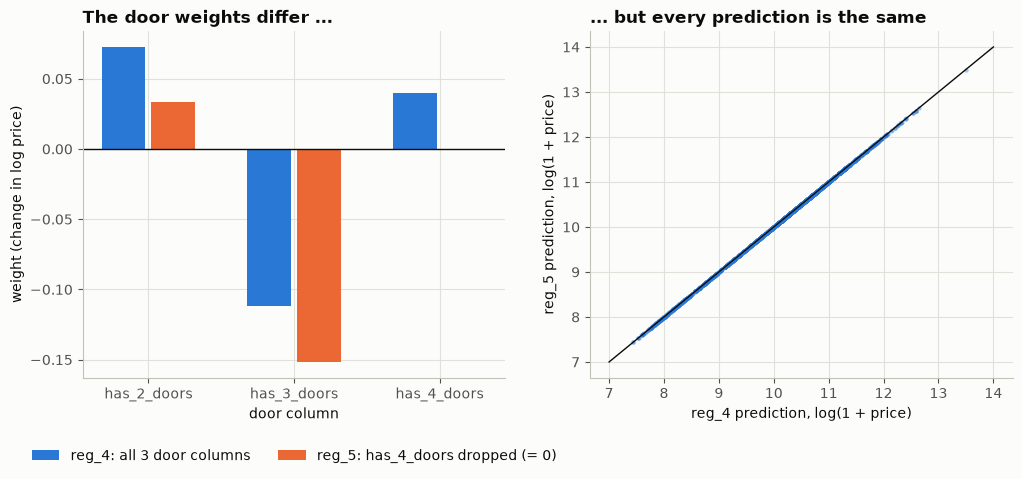

largest difference between the two models' predictions: 3.6e-14


In [24]:
# reg_4 (all 3 door columns, one pick among infinitely many answers) vs. reg_5 (2 door columns, the unique answer).
valid = dataflow(df_corrected)['df_valid']
prediction_4 = reg_4.predict(valid[base + ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors']])
prediction_5 = reg_5.predict(valid[base + ['car_age'] + door_columns])

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))

doors = ['has_2_doors', 'has_3_doors', 'has_4_doors']
x = np.arange(3)
left.bar(x - 0.17, reg_4.coef_[-3:], width=0.3, color=BLUE, label='reg_4: all 3 door columns')
left.bar(x + 0.17, [*reg_5.coef_[-2:], 0], width=0.3, color=ORANGE, label='reg_5: has_4_doors dropped (= 0)')
left.axhline(0, color=INK, linewidth=1)
left.set_xticks(x, doors)
left.set_title('The door weights differ ...')
left.set_xlabel('door column')
left.set_ylabel('weight (change in log price)')
left.legend(loc='upper center', bbox_to_anchor=(0.5, -0.17), ncols=2)

right.scatter(prediction_4, prediction_5, s=10, color=BLUE, alpha=0.4, linewidths=0)
right.plot([7, 14], [7, 14], color=INK, linewidth=1)
right.set_title('... but every prediction is the same')
right.set_xlabel('reg_4 prediction, log(1 + price)')
right.set_ylabel('reg_5 prediction, log(1 + price)')
plt.show()

print(f'largest difference between the two models\' predictions: {np.abs(prediction_4 - prediction_5).max():.1e}')

**Reading the chart.** On the left are the three door weights of `reg_4` (blue, all three door columns) and `reg_5` (orange, with `has_4_doors` dropped, so its weight is 0 by definition). The vertical axis is the weight, a change in log price. On the right, each dot is one validation car, with `reg_4`'s prediction on the horizontal axis and `reg_5`'s on the vertical axis; the black line is where the two models agree.

The weights look like two different models: 0.073 against 0.033 for 2 doors, and a 4-door weight of 0.040 against 0. Yet every dot lies exactly on the line: the largest difference between the two models' predictions is $3.6 \times 10^{-14}$, which is rounding noise. What the two models share are the *differences* between door weights, and those are all the predictions depend on: 0.073 − 0.040 = 0.033.

The RMSE is the same as `reg_4`'s (the predictions were never the problem), but now the rank is full, there is exactly one answer, and it is the one the NumPy notebook found: 2-door cars are 3.4% more expensive and 3-door cars 14.1% cheaper than a comparable 4-door car.

That's why dropping a column is still the right fix even though scikit-learn copes without it. In the NumPy notebook, the 6 doorless cars only "rescued" the model by accident; dropping a column works whatever the data looks like, and it gives weights you can actually read.

(Section 8 of the NumPy notebook shows, over 40 random splits, that the doors don't really improve the model. That result doesn't depend on the library, so it isn't repeated here.)

## 8. The make of the car

The make was the feature that really helped in the NumPy notebook (0.5143 → 0.4478), and also where the model broke twice more:

1. All 48 make columns together add up to the bias column: the dummy variable trap again (RMSE 111.3).
2. After dropping one make, it was *still* broken, because `popularity` is a per-make constant, so the make columns can rebuild it exactly (RMSE 95.2). Dropping `popularity` fixed it.

We build the make columns the same way.

In [25]:
# One column per make. We sort the makes so that the column order depends on the data, not on the
# order the rows happen to be stored in.
all_makes = sorted(df.make.unique())

for make in all_makes:
    df[f'make_is_{make}'] = (df.make == make).astype(int)

# df_corrected was a copy taken in section 6, so it does not have the new columns yet. Rebuild it.
df_corrected = df.drop(df[df.number_of_doors == 0].index)

# As in section 7, we drop the most frequent category and make it the reference.
reference_make = df_corrected.make.value_counts().index[0]
make_columns = [f'make_is_{make}' for make in all_makes if make != reference_make]

print('makes:', len(all_makes))
print('reference:', reference_make, f'({(df_corrected.make == reference_make).sum()} cars)')
print('columns used:', len(make_columns))

makes: 48
reference: chevrolet (1123 cars)
columns used: 47


First, the version that broke the NumPy model twice over: all 48 make columns **and** `popularity`.

In [26]:
all_make_columns = [f'make_is_{make}' for make in all_makes]

features = base + ['car_age'] + door_columns + all_make_columns
reg_6, error = train_and_score(df_corrected, features)
print('rank:', reg_6.rank_, 'of', len(features))
print('rmse:', error)

rank: 53 of 55
rmse: 0.44779197919780084


No error again, and already the good RMSE. `rank_` shows that scikit-learn found **two** redundant columns, one for each trap, and quietly worked around both.

Now the model the NumPy notebook ended up with: 47 make columns (chevrolet is the reference) and no `popularity`.

In [27]:
base_without_popularity = ['engine_hp', 'highway_mpg', 'city_mpg']
features = base_without_popularity + ['car_age'] + door_columns + make_columns

reg_7, error = train_and_score(df_corrected, features)
print('rank:', reg_7.rank_, 'of', len(features))
print('rmse:', error)

rank: 53 of 53
rmse: 0.4477919791977993


Full rank, and the same 0.4478 as the NumPy notebook. Each make weight is now a percentage difference from a Chevrolet with the same horsepower, fuel economy, age and doors.

## 9. Ridge regression

In the NumPy notebook, ridge regression was first of all a rescue. On 9 of 40 random splits, a rare make (genesis, spyker, alfa romeo, mclaren or bugatti, with 3 to 5 cars each) landed entirely outside the training set. Its column was then all zeros, and `np.linalg.inv` raised `LinAlgError`. Seed 20 was one of those splits. Let's try it with `LinearRegression`:

In [28]:
# Seed 20 puts all 3 genesis cars outside the training set, so make_is_genesis is all zeros there.
reg_20, error = train_and_score(df_corrected, features, seed=20)
print('rank:', reg_20.rank_, 'of', len(features))
print('rmse:', error)
print('genesis weight:', reg_20.coef_[features.index('make_is_genesis')])

rank: 52 of 53
rmse: 0.45430220420753326
genesis weight: 4.440892098500626e-16


The third disguise of the same rule, handled the same way: rank 52 of 53, no error, and the all-zero column simply gets a weight of 0 (up to rounding), so a Genesis is priced like a Chevrolet with the same specs. The RMSE, 0.4543, is what ridge gave on this split in the NumPy notebook.

So `LinearRegression` doesn't need ridge in order to train. Ridge's other job still matters, though: keeping the weights small. Some make weights are fitted on only 3 cars, and ridge pulls such weights toward 0 unless the data insists. scikit-learn's `Ridge` minimises

$$\text{sum of squared errors} + \alpha \cdot \text{sum of squared weights}$$

which leads to the same equation as the NumPy notebook's $w = (X^T X + rI)^{-1} X^T y$: scikit-learn's `alpha` is our `r`. Like our NumPy version, it doesn't penalise the bias.

### A detour: the `ridge_regression` function

scikit-learn also has a plain function, `ridge_regression`, which returns the weights directly. It looks like the natural replacement for our `ridge_regression_training`, but it has a catch.

In [29]:
from sklearn.linear_model import ridge_regression

dataset = dataflow(df_corrected)
df_train = dataset['df_train']
df_valid = dataset['df_valid']

X_train, y_train = df_train[features], df_train['msrp_log']
X_valid, y_valid = df_valid[features], df_valid['msrp_log']

coef, intercept = ridge_regression(X_train, y_train, alpha=0.0001, return_intercept=True)

print('intercept:', intercept)
print('rmse:', root_mean_squared_error(y_valid, X_valid.values @ coef + intercept))

intercept: 1.4927381059941083
rmse: 1.2376610584855345


C:\my_files\Car-Price-Prediction-Project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


An RMSE far above 0.4478, and a `ConvergenceWarning`.

Asking `ridge_regression` for the intercept (`return_intercept=True`) silently switches it to a solver called `'sag'`. Unlike the normal equation, `'sag'` doesn't solve the problem in one go: it improves the weights a little at a time and stops after a fixed number of rounds (`max_iter`). The warning says it ran out of rounds before reaching the answer, so these weights are half-finished. It is also random: run the cell again and the last digits change.

The root cause is one the NumPy notebook already lists under "what to try next": our columns are on very different scales. `engine_hp` runs into the hundreds while the make columns are 0 or 1, and step-by-step solvers like `'sag'` crawl on such data. Rescale every column first (`StandardScaler` subtracts each column's mean and divides by its standard deviation) and it gets there:

In [30]:
from sklearn.preprocessing import StandardScaler

# Learn each column's mean and standard deviation on the training set, and apply the same to both sets.
scaler = StandardScaler().fit(X_train)
coef, intercept = ridge_regression(scaler.transform(X_train), y_train, alpha=0.0001, return_intercept=True)

print('rmse:', root_mean_squared_error(y_valid, scaler.transform(X_valid) @ coef + intercept))

rmse: 0.44778710956026696


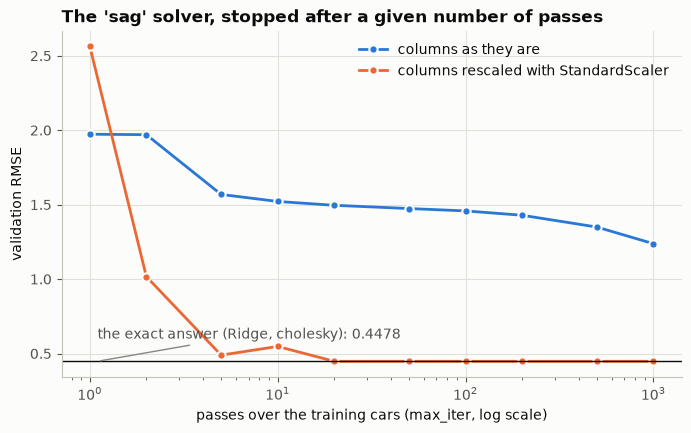

after 1000 passes: 1.2377 with the columns as they are, 0.4478 rescaled
rescaled, within 0.001 of 0.4478 from 20 passes on


In [31]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Stop 'sag' after a fixed number of passes over the training cars, with and without rescaling.
passes = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
X_train_scaled, X_valid_scaled = scaler.transform(X_train), scaler.transform(X_valid)
rmse_raw, rmse_scaled = [], []
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)     # we already know it will not finish
    for n in passes:
        coef, intercept = ridge_regression(X_train, y_train, alpha=0.0001, return_intercept=True,
                                           max_iter=n, random_state=0)
        rmse_raw.append(root_mean_squared_error(y_valid, X_valid.values @ coef + intercept))
        coef, intercept = ridge_regression(X_train_scaled, y_train, alpha=0.0001, return_intercept=True,
                                           max_iter=n, random_state=0)
        rmse_scaled.append(root_mean_squared_error(y_valid, X_valid_scaled @ coef + intercept))

fig, ax = plt.subplots()
ax.plot(passes, rmse_raw, 'o-', color=BLUE, markeredgecolor=BACKGROUND, markeredgewidth=1.5, label='columns as they are')
ax.plot(passes, rmse_scaled, 'o-', color=ORANGE, markeredgecolor=BACKGROUND, markeredgewidth=1.5,
        label='columns rescaled with StandardScaler')
ax.axhline(0.447792, color=INK, linewidth=1)
ax.annotate('the exact answer (Ridge, cholesky): 0.4478', xy=(1.1, 0.447792), xytext=(1.1, 0.6), color='#52514e',
            arrowprops=dict(arrowstyle='-', color=GREY))
ax.set_xscale('log')
ax.set_title("The 'sag' solver, stopped after a given number of passes")
ax.set_xlabel('passes over the training cars (max_iter, log scale)')
ax.set_ylabel('validation RMSE')
ax.legend()
plt.show()

print(f'after {passes[-1]} passes: {rmse_raw[-1]:.4f} with the columns as they are, {rmse_scaled[-1]:.4f} rescaled')
print(f'rescaled, within 0.001 of 0.4478 from {next(n for n, e in zip(passes, rmse_scaled) if e < 0.447792 + 0.001)} passes on')

**Reading the chart.** The horizontal axis is the number of passes over the training cars that `'sag'` is allowed (log scale). The vertical axis is the validation RMSE of the weights it has reached by then, and the black line is the exact answer from the direct solver.

With the columns as they are (blue), `'sag'` creeps: after 1,000 passes it is still at 1.2377, nearly three times the exact 0.4478. With every column rescaled (orange), it is within 0.001 of the exact answer from 20 passes on. The data, the solver and the penalty are the same; only the units of the columns changed. (`random_state=0` fixes the order in which `'sag'` visits the cars, so unlike the cell above, this chart comes out the same on every run.)

For the rest of the notebook we use the `Ridge` class instead. It works like `LinearRegression` (`fit`, `predict`, `intercept_`, `coef_`), and on data like ours it picks the `'cholesky'` solver, which solves the ridge equation directly, in one go, like our NumPy function did. No rescaling needed.

In [32]:
from sklearn.linear_model import Ridge

ridge, error = train_and_score(df_corrected, features, model=Ridge(alpha=0.0001))
print('solver:', ridge.solver_)
print('rmse:  ', error)

solver: cholesky
rmse:   0.4477919310567771


0.447792, the NumPy notebook's value for r = 0.0001. As there, we choose `alpha` on the validation set:

In [33]:
print('alpha      validation rmse')
for alpha in [0.0001, 0.001, 0.01, 0.1, 0.3, 1, 3, 10, 100]:
    _, error = train_and_score(df_corrected, features, model=Ridge(alpha=alpha))
    print(f"{alpha:<10} {error:.6f}")

alpha      validation rmse
0.0001     0.447792
0.001      0.447792
0.01       0.447787
0.1        0.447766
0.3        0.447806
1          0.448314
3          0.450286
10         0.456663
100        0.484079


The same numbers as in section 11 of the NumPy notebook. The best `alpha` is 0.1, and, as there, it improves the RMSE only in the fifth decimal place: ridge doesn't make this model more accurate. We use `alpha = 0.1` for the final model.

## 10. The final model: one look at the test set

As in the NumPy notebook: train one last model on the training **and** validation cars together, with the features and the `alpha` chosen above, and evaluate it on the test set exactly once.

In [34]:
dataset = dataflow(df_corrected)
df_train_valid = dataset['df_train_valid']
df_test = dataset['df_test']

final_model = Ridge(alpha=0.1).fit(df_train_valid[features], df_train_valid['msrp_log'])
test_predictions = final_model.predict(df_test[features])

print(f"trained on {len(df_train_valid)} cars, tested on {len(df_test)} cars")
print(f"test rmse: {root_mean_squared_error(df_test['msrp_log'], test_predictions):.4f}")

# In dollars: how far from the real price is a typical prediction?
off_by = (np.expm1(test_predictions) - df_test.msrp) / df_test.msrp
print(f"median error: {off_by.abs().median():.1%} of the real price")

trained on 9525 cars, tested on 2383 cars
test rmse: 0.4528
median error: 25.2% of the real price


A test RMSE of 0.4528 and a median error of 25.2% of the real price: the same final result as the NumPy notebook.

## 11. NumPy vs scikit-learn, side by side

Validation RMSE on seed 0 unless stated otherwise. The NumPy column comes from the results table in section 13 of the NumPy notebook.

| model | data | NumPy | scikit-learn | what happened |
|---|---|---|---|---|
| base features | `df` | 0.7734 | 0.7734 | same |
| + `car_age` | `df` | 0.5301 | 0.5301 | same |
| + `car_age` + 3 door columns | `df` | 0.5279 | 0.5279 | same |
| + `car_age` + 3 door columns | `df_corrected` | 16.5354 | 0.5143 | NumPy: silent garbage. scikit-learn: rank 7 of 8, no warning |
| + `car_age` + 2 door columns | `df_corrected` | 0.5143 | 0.5143 | same, rank 7 of 7 |
| + 48 make columns, with `popularity` | `df_corrected` | 111.2961 | 0.4478 | NumPy: silent garbage. scikit-learn: rank 53 of 55, no warning |
| + 47 make columns, no `popularity` | `df_corrected` | 0.4478 | 0.4478 | same, rank 53 of 53 |
| the same, seed 20 (no genesis in training) | `df_corrected` | `LinAlgError` | 0.4543 | scikit-learn: rank 52 of 53, no warning |
| … and ridge, α = r = 0.1 | `df_corrected` | 0.4478 | 0.4478 | same |
| **final model, test set** | `df_corrected` | **0.4528** | **0.4528** | same |

### What the comparison shows

- **Where the problem has one answer, the two agree**, to at least 13 decimal places. Solving the normal equation by hand was right.
- **Where it doesn't, they fail differently.** NumPy's `inv` returned confident nonsense twice and raised an error once. scikit-learn's least-squares solver quietly picked one of the infinitely many answers every time, so its predictions stayed good, but it never said a word. The only trace is `rank_` being smaller than the number of columns.
- **The rule still applies with a library.** No column may be an exact recipe of the other columns. Break it and scikit-learn keeps the predictions working, but the weights of the redundant columns stop meaning anything, and nothing tells you unless you check `rank_`.
- **Not every scikit-learn tool is that forgiving.** `ridge_regression(..., return_intercept=True)` switched to a step-by-step solver that stopped half-way on our unscaled columns. Warnings are worth reading.

### What to try next

The NumPy notebook's list applies here too: rescale the columns, add more categorical features, fix the remaining `fillna(0)` damage, drop the placeholder \$2,000 prices, and use cross-validation. scikit-learn makes several of these short: `OneHotEncoder` and `StandardScaler` can be chained with the model in a `Pipeline`, and `cross_val_score` runs the cross-validation.